In [11]:
import sys
import os
import math
import glob
import torch
from torchsummary import summary
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS, 
    NUM_CLASSES
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.layers import QuantizedLayerMixin

CONFIG = {
    "baseline_path": BASELINE_MODEL_PATH,
    "quant_model_name": "Aff_INT8_Dynamic", # Nur hier ändern!
    "batch_size": 32,
    "vis_samples": 50
}

sns.set_theme(style="whitegrid")

In [12]:
def _fix_quantization_dtypes(module, method='symmetric', bits=8):
    """
    Interne Hilfsfunktion: Setzt Flags und repariert Float->Int Casts für einen Layer.
    """
    module.quant_method = method
    module.num_bits = bits
    module.quant_mode = True
    
    if hasattr(module, 'act_scale') and module.act_scale.item() != 1.0:
        module.activation_calibrated = True
        
    if method == 'affine':
        target_dtype = torch.uint8
    else: # symmetric / power2
        target_dtype = torch.int8
        
    if hasattr(module, 'weight') and module.weight.dtype == torch.float32:
        module.weight = nn.Parameter(module.weight.data.to(target_dtype), requires_grad=False)

def load_model(model_class, num_classes, model_path, quant_config=None):
    # 1. Initialize (Model is on DEVICE, e.g., 'cuda')
    model = model_class(num_classes=num_classes).to(DEVICE)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modell nicht gefunden: {model_path}")

    # 2. Transform the model
    if quant_config:
        from torchao.quantization import quantize_, Int8WeightOnlyConfig, int8_dynamic_activation_int8_weight
        if quant_config['method'] == 'symmetric':
            quantize_(model, Int8WeightOnlyConfig(version=2))
        elif quant_config['method'] == 'affine':
            quantize_(model, int8_dynamic_activation_int8_weight())

    # --- THE FIX: MAP STORAGE TO CURRENT DEVICE ---
    # Use map_location=DEVICE to force 'cuda:0' labels to match your 'DEVICE' variable
    state_dict = torch.load(model_path, map_location=DEVICE)
    
    # 3. Clean keys and ensure every tensor is strictly on the model's device
    clean_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace("_orig_mod.", "")
        # Explicitly move the tensor to the model's current device to be safe
        clean_state_dict[new_key] = v.to(DEVICE)
        
    # 4. Load with assign=True
    model.load_state_dict(clean_state_dict, assign=True)
    
    model.eval()
    return model

In [13]:
def get_all_predictions(model, data_loader):
    """
    Führt Inferenz auf dem gesamten Loader durch und gibt rohe Listen/Arrays zurück.
    Kein Plotting hier! Nur Datenverarbeitung.
    """
    model.eval()
    all_preds = []
    all_targets = []

    sample_images = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            data = data.to(DEVICE)

            output = model(data)
            pred = output.argmax(dim=1).cpu().numpy()

            all_preds.extend(pred)
            all_targets.extend(target.numpy())

            if i == 0:
                sample_images = data.cpu()
            
    return {
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "sample_images": sample_images
    }

def print_metrics(results_dict, model_name="Model"):
    # TODO: Berechne Accuracy, Precision, Recall basierend auf results_dict['preds'] und ['targets']
    # Nutze sklearn classification_report
    acc = accuracy_score(results_dict['targets'], results_dict['preds'])
    error_rate = 1.0 - acc

    print(f"\n--- Performance: {model_name} ---")
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    print("-" * 40)

    print(classification_report(results_dict['targets'], results_dict['preds'], digits=4))

In [14]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    """Plottet eine saubere Confusion Matrix der Top-Klassen"""
    # Wir nehmen nur die häufigsten Klassen, damit der Plot lesbar bleibt
    from collections import Counter
    TOP_N = 15
    
    counts = Counter(targets)
    top_classes_idx = [c for c, _ in counts.most_common(TOP_N)]
    
    # Filtern
    mask = np.isin(targets, top_classes_idx) & np.isin(preds, top_classes_idx)
    filt_targets = targets[mask]
    filt_preds = preds[mask]
    
    cm = confusion_matrix(filt_targets, filt_preds, labels=top_classes_idx)
    
    # Namen mappen
    if class_names:
        labels = [class_names[i] for i in top_classes_idx]
    else:
        labels = top_classes_idx

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{title} (Top {TOP_N} Classes)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, num_samples=32):
    """
    Zeigt Bilder im Raster an.
    Farben: Grün (beide korrekt), Rot (beide falsch), Orange (Quantisierung weicht ab).
    """
    # Wir nutzen nur so viele Bilder, wie wir haben
    n = min(len(images), num_samples, len(preds_base))
    
    cols = 8
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.0 * rows))
    axes = axes.flatten()
    
    print(f"Visualisiere {n} Beispiele...")
    
    for i in range(n):
        ax = axes[i]
        
        # Bild normalisieren für Anzeige (angenommen -1..1 Range)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        p_base = preds_base[i]
        p_quant = preds_quant[i]
        true_lbl = targets[i]
        
        # Logik für Titel-Farbe
        is_diff = (p_base != p_quant)
        is_correct = (p_quant == true_lbl)
        
        if is_diff:
            color = 'orange'
            box_text = "DIFF"
        elif is_correct:
            color = 'green'
            box_text = "OK"
        else:
            color = 'red'
            box_text = "ERR"
            
        # Klassen-Namen holen
        if class_names and p_quant < len(class_names):
            name_q = class_names[p_quant]
        else:
            # If it's a padding index (150/151) or names are missing
            name_q = f"Unk({p_quant})"
        # name_t = class_names[true_lbl] if class_names else str(true_lbl)
        
        title = f"Q: {name_q}\n[{box_text}]"
        ax.set_title(title, color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    # Restliche Achsen ausschalten
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_weight_distribution(model, layer_type=nn.Conv2d):
    """Zeigt die Gewichtsverteilung als Boxplot"""
    data = []
    labels = []
    
    for name, module in model.named_modules():
        if isinstance(module, layer_type):
            w = module.weight.detach().cpu().numpy().flatten()
            data.append(w)
            labels.append(name)
            
    if not data:
        print("Keine Layer für Weight-Plot gefunden.")
        return

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=labels, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung ({layer_type.__name__})")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
            Conv2d-2           [-1, 64, 64, 64]          18,496
            Conv2d-3          [-1, 128, 64, 64]          73,856
            Conv2d-4          [-1, 256, 64, 64]         295,168
 AdaptiveAvgPool2d-5            [-1, 256, 2, 2]               0
           Dropout-6                 [-1, 1024]               0
            Linear-7                 [-1, 1024]       1,049,600
            Linear-8                  [-1, 152]         155,800
Total params: 1,593,816
Trainable params: 1,593,816
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 15.02
Params size (MB): 6.08
Estimated Total Size (MB): 21.15
----------------------------------------------------------------
------------------------------------

c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\torchao\utils.py:390: UserWarning: `int8_dynamic_activation_int8_weight` is deprecated and will be removed in a future release. Please use `Int8DynamicActivationInt8WeightConfig` instead. Example usage:
    quantize_(model, Int8DynamicActivationInt8WeightConfig(...))
  warnings.warn(



--- Performance: Baseline Float32 ---
Accuracy:   0.8900 (89.00%)
Error Rate: 0.1100 (11.00%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    0.8889    0.9412         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
          10     0.8571    1.0000    0.9231         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          13     1.0000    0.9167    0.9565        12
          14     0.6000    0.7500    0.6667         4

c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dominic\Documents\ResearchProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

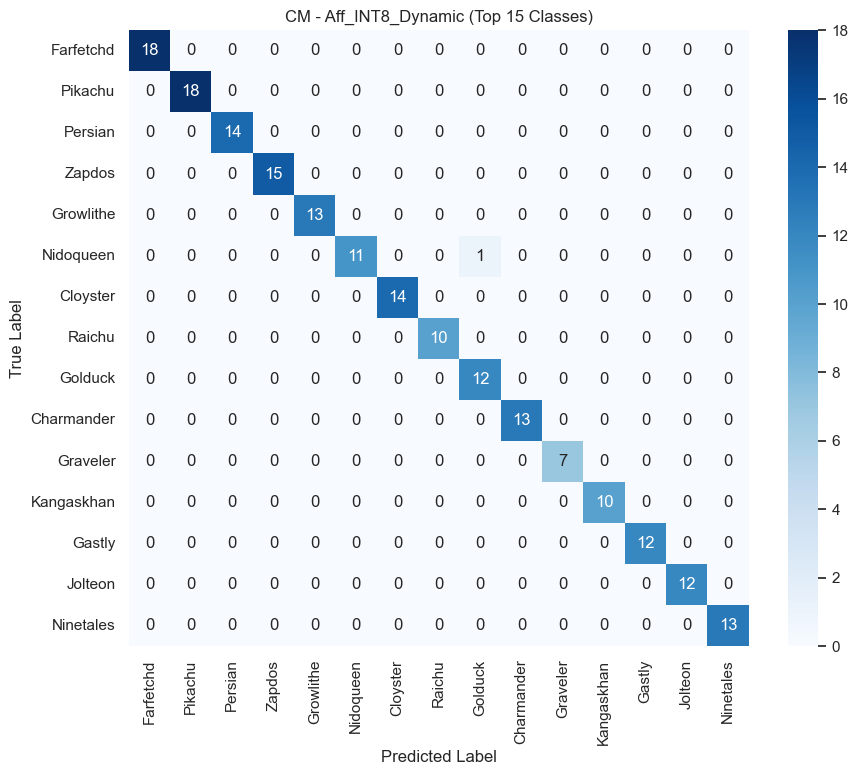

Visualisiere 50 Beispiele...


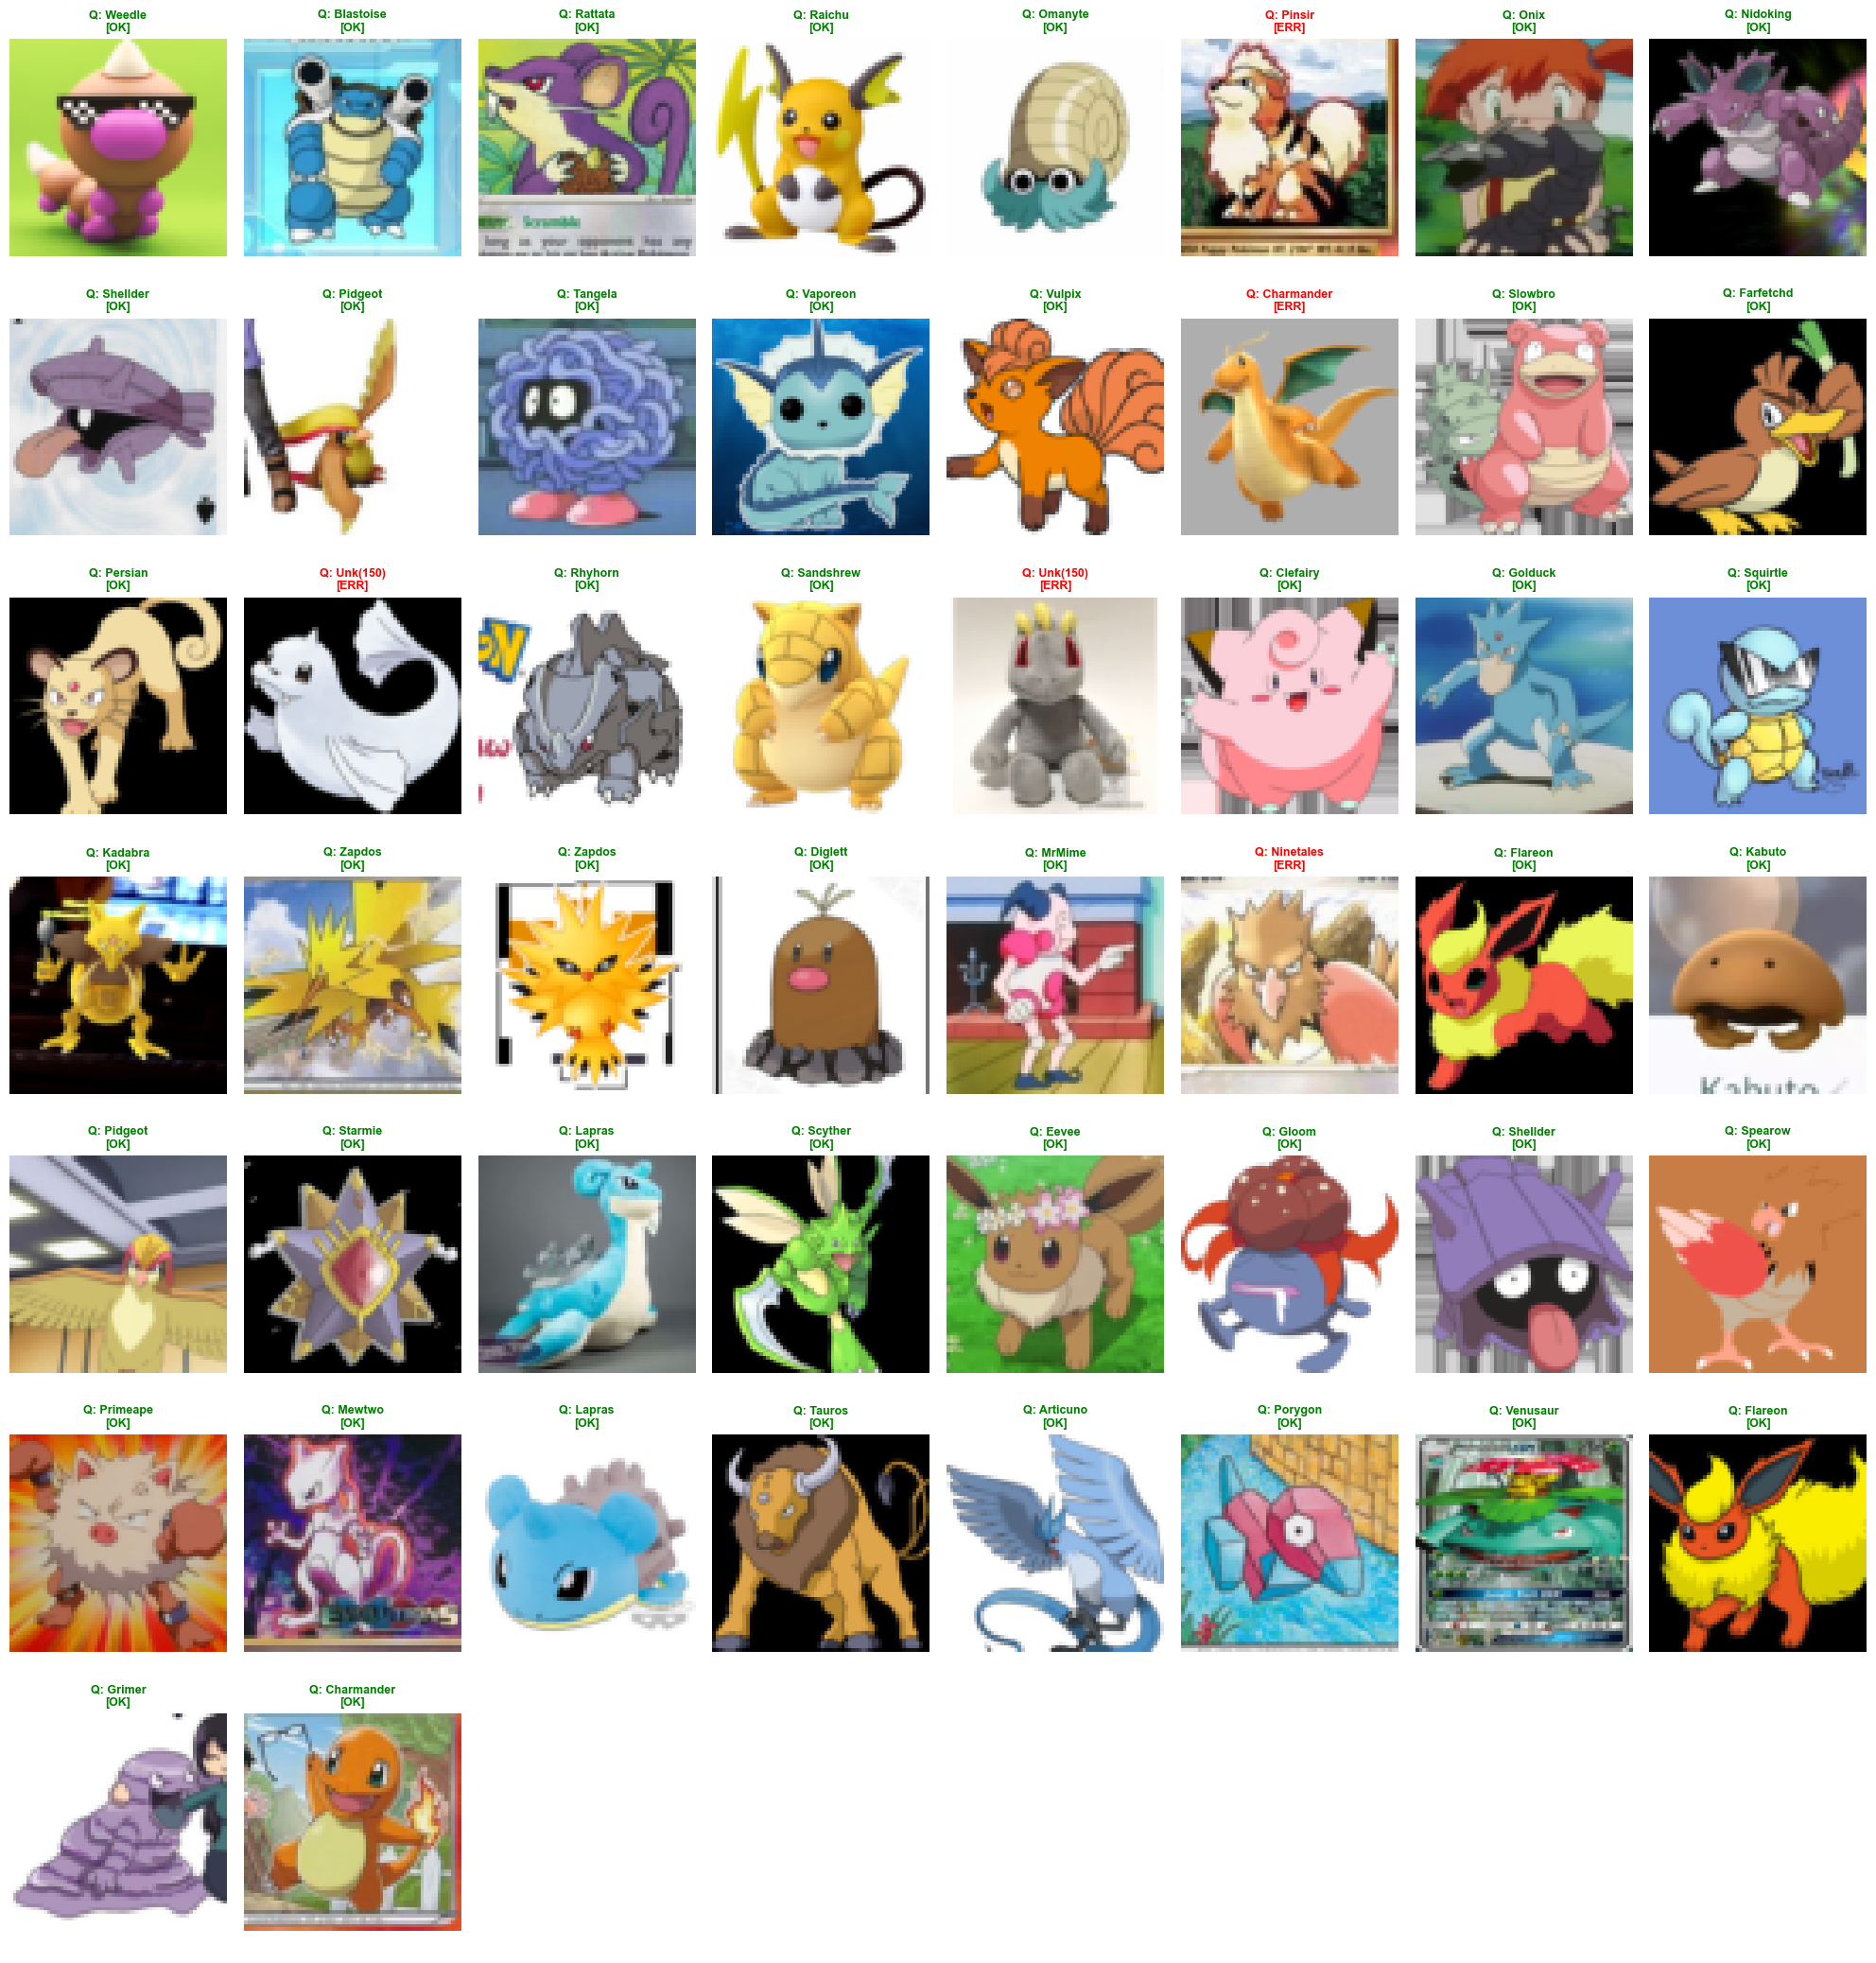

Analysiere Gewichtsverteilung der Baseline...


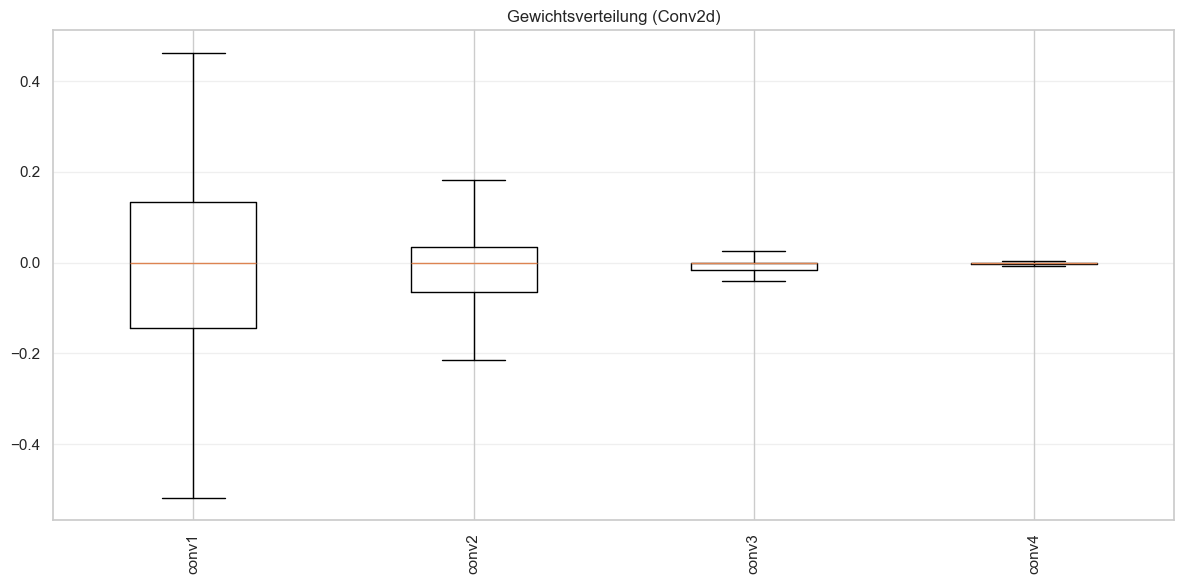

In [15]:
train_loader, test_loader, num_classes = get_data_loaders()
# Versuche Klassennamen zu finden
class_names = getattr(test_loader.dataset, 'classes', None)
if not class_names and hasattr(test_loader.dataset, 'dataset'):
    class_names = getattr(test_loader.dataset.dataset, 'classes', None)

# 2. Config ableiten (Automatisch aus dem Namen)
q_name = CONFIG['quant_model_name']
q_method = 'affine' if 'Aff' in q_name else 'symmetric'
if 'Po2' in q_name: q_method = 'power2'
q_bits = 4 if 'INT4' in q_name else 8

# 3. Modelle laden
# A) Baseline
baseline_path = BASELINE_MODEL_PATH
baseline_model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

if os.path.exists(baseline_path):
    state_dict = torch.load(baseline_path, map_location=DEVICE)
    
    old_weight = state_dict['fc2.weight']
    old_bias = state_dict['fc2.bias']
    
    # Get the actual number of classes currently in the checkpoint
    current_checkpoint_classes = old_weight.shape[0]
    
    # Only pad if it is not already 152
    if current_checkpoint_classes != 152:
        new_weight = torch.zeros((152, 1024), device=DEVICE)
        new_bias = torch.zeros((152,), device=DEVICE)
        
        # Use the actual size of old_weight to slice
        new_weight[:current_checkpoint_classes, :] = old_weight
        new_bias[:current_checkpoint_classes] = old_bias
        
        state_dict['fc2.weight'] = new_weight
        state_dict['fc2.bias'] = new_bias
    
    baseline_model.load_state_dict(state_dict, strict=False)

summary(baseline_model, input_size=(3,64,64))

# B) Quantized
q_path = os.path.join(QUANTIZED_MODELS, f"model_{q_name}.pt")
quantized_model = load_model(
    CNN, 
    NUM_CLASSES,  # This should be 152 in your config.py
    q_path, 
    quant_config={'method': q_method, 'bits': q_bits}
)

summary(quantized_model, input_size=(3,64,64))

# 4. Inferenz & Metriken
res_base = get_all_predictions(baseline_model, test_loader)
res_quant = get_all_predictions(quantized_model, test_loader)

print_metrics(res_base, "Baseline Float32")
print_metrics(res_quant, f"Quantized {q_name}")

# 5. Visualisierung
# A) Verwirrungsmatrix (Vergleich)
plot_confusion_matrix(res_quant['targets'], res_quant['preds'], class_names, title=f"CM - {q_name}")

# B) Visueller Vergleich (Bilder)
# Wir nutzen die 'sample_images' aus dem Baseline-Result (da identisch)
# und nehmen die ersten N Predictions aus den Gesamt-Ergebnissen
plot_visual_comparison(
    res_base['sample_images'], 
    res_base['preds'][:len(res_base['sample_images'])], 
    res_quant['preds'][:len(res_base['sample_images'])], 
    res_base['targets'][:len(res_base['sample_images'])],
    class_names,
    num_samples=CONFIG['vis_samples']
)

# C) Gewichts-Analyse (Optional)
print("Analysiere Gewichtsverteilung der Baseline...")
plot_weight_distribution(baseline_model)